<a href="https://colab.research.google.com/github/Lingeshkumar24-code/deep-learning/blob/main/DL_assigment_IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Bidirectional
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
print("Training Reviews :", len(X_train))
print("Testing Reviews :", len(X_test))

print("First Review:")
print(X_train[0])

print("Label:", y_train[0])

Training Reviews : 25000
Testing Reviews : 25000
First Review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 3

In [4]:
max_length = 200

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding='post')

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding='post')

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


In [5]:
simple_rnn = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=128,
              input_length=max_length),

    SimpleRNN(64),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [6]:
simple_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
simple_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
history1 = simple_rnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.5324 - loss: 0.6845 - val_accuracy: 0.5532 - val_loss: 0.6720
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.6447 - loss: 0.5792 - val_accuracy: 0.5964 - val_loss: 0.6537
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.7193 - loss: 0.4645 - val_accuracy: 0.5478 - val_loss: 0.7584
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.7453 - loss: 0.3841 - val_accuracy: 0.5636 - val_loss: 0.8139
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.7567 - loss: 0.3730 - val_accuracy: 0.5604 - val_loss: 0.8609


In [9]:
loss1, accuracy1 = simple_rnn.evaluate(X_test, y_test)

print("Simple RNN Accuracy:", accuracy1)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5519 - loss: 0.8679
Simple RNN Accuracy: 0.5518800020217896


In [10]:
pred1 = simple_rnn.predict(X_test)

pred1 = (pred1 > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step


In [11]:
print(classification_report(y_test, pred1))

              precision    recall  f1-score   support

           0       0.54      0.72      0.62     12500
           1       0.58      0.38      0.46     12500

    accuracy                           0.55     25000
   macro avg       0.56      0.55      0.54     25000
weighted avg       0.56      0.55      0.54     25000



In [12]:
print(confusion_matrix(y_test, pred1))

[[8998 3502]
 [7701 4799]]


In [13]:
bidir_rnn = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=128,
              input_length=max_length),

    Bidirectional(SimpleRNN(64)),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
bidir_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history2 = bidir_rnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 104ms/step - accuracy: 0.5413 - loss: 0.6858 - val_accuracy: 0.5966 - val_loss: 0.6613
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 106ms/step - accuracy: 0.7097 - loss: 0.5707 - val_accuracy: 0.6018 - val_loss: 0.6640
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.8460 - loss: 0.3550 - val_accuracy: 0.5836 - val_loss: 0.8011
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.9545 - loss: 0.1339 - val_accuracy: 0.7136 - val_loss: 0.7251
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.9907 - loss: 0.0358 - val_accuracy: 0.6576 - val_loss: 1.0264


In [16]:
loss2, accuracy2 = bidir_rnn.evaluate(X_test, y_test)

print("Bidirectional RNN Accuracy:", accuracy2)

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6530 - loss: 1.0577
Bidirectional RNN Accuracy: 0.6530399918556213


In [17]:
pred2 = bidir_rnn.predict(X_test)

pred2 = (pred2 > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step


In [18]:
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           0       0.65      0.67      0.66     12500
           1       0.66      0.63      0.65     12500

    accuracy                           0.65     25000
   macro avg       0.65      0.65      0.65     25000
weighted avg       0.65      0.65      0.65     25000



In [19]:
print("Simple RNN Accuracy :", accuracy1)

print("Bidirectional RNN Accuracy :", accuracy2)

Simple RNN Accuracy : 0.5518800020217896
Bidirectional RNN Accuracy : 0.6530399918556213


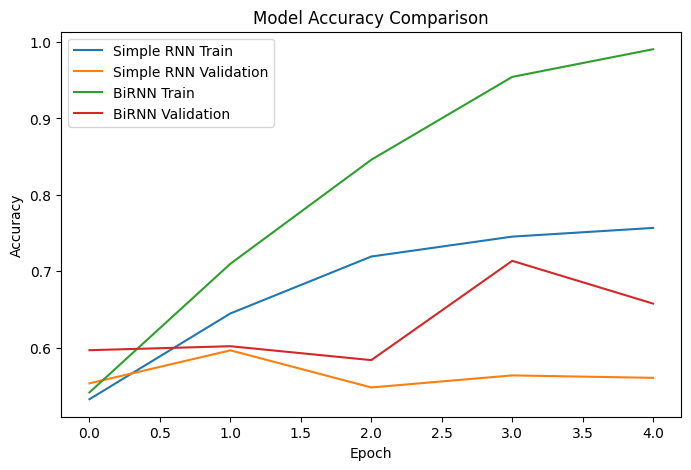

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history1.history['accuracy'], label='Simple RNN Train')

plt.plot(history1.history['val_accuracy'], label='Simple RNN Validation')

plt.plot(history2.history['accuracy'], label='BiRNN Train')

plt.plot(history2.history['val_accuracy'], label='BiRNN Validation')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.title("Model Accuracy Comparison")

plt.show()